# Haploblock reframe — r2 x eps sweep

**Question:** instead of estimating founder frequencies for all 231 founders
(many of which are k-mer-indistinguishable and unidentifiable), collapse each
LD block to its *distinct haplotypes* and estimate haplotype-class frequencies
instead. This notebook sweeps the two free parameters that define "distinct
haplotype" and shows the size/accuracy trade-off, on the g0-231 equimolar
simulation (Chr1 only).

## Acronyms / terms

| Term | Meaning |
|---|---|
| **r2** (r²) | The LD threshold used to cut the genome into blocks (`CompleteLDPartition` on kMate's own k-mer/bubble panel). Higher r2 -> tighter LD required to stay in one block -> **smaller, more numerous blocks**. r2=0.10 gives 18 (large, ~1.3 Mb) blocks on Chr1; r2=0.40 gives 788 (small, ~8.6 kb) blocks. |
| **eps** (ε) | The haplotype-merge threshold used *within* a block. Two founders are put in the same haploblock if the fraction of the block's k-mers on which they disagree (Hamming distance, complete-linkage clustering) is <= eps. eps=0.00 = exact identity (only byte-identical founders merge); eps=0.05 = founders differing on up to 5% of the block's k-mers still merge. |
| **K_b** | Number of distinct haploblocks (haplotype classes) resolved in a block after merging at a given eps. This is "the real number of identifiable things" in that block, vs. the naive assumption of 231 founders. |
| **h** | The per-founder frequency vector kMate's EM estimates for a block (231 numbers, one per founder, summing to 1). A haploblock's estimated frequency = sum of `h` over its member founders (valid post-hoc, since EM only identifies founders up to their k-mer signature). |
| **TVD** | Total-variation distance: `0.5 * sum(|estimated haploblock freq - true haploblock freq|)`, between the EM-estimated and the ground-truth (equimolar, 1/231 per founder before collapsing) haploblock frequency distributions. Scale-fair (both distributions sum to 1, so TVD is comparable across different K_b) -- unlike classMAE, which mechanically shrinks as K_b grows. **Lower TVD = better recovery.** |
| **g0** | Generation-0 (founder) simulation: 231 founders mixed in known, equimolar (1/231 each) proportions -- the synthetic benchmark used here since ground truth is known exactly. |
| **EM** | The kMate expectation-maximization step that estimates per-founder relative abundance `h` from pooled k-mer counts. |
| **median / p90** | Across all blocks at a given (r2, eps): the 50th and 90th percentile. p90 captures the *tail* -- a handful of hard blocks that don't collapse as cleanly as the typical (median) block. |

**How to read the plots:** for a decision, you want small **K_b** (collinearity
really collapsed, not still hiding 231 things) *and* small **TVD** (the
resulting haploblock frequencies are still estimated accurately). The scatter
in the last panel shows this trade-off directly -- down-and-left is better.


In [1]:

import numpy as np, scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster

ROOT = "/global/scratch/users/tbellg/kmate"
OUT = f"{ROOT}/analysis/grenenet_selection/blocks/hap_blocks/bench_g0_231"
KMPRE = f"{ROOT}/benchmarks/p231/data/kmer_pa_p231_filt2inv/kmer_pa_Chr1"
F = 231
R2S = ["0.10", "0.20", "0.30", "0.40"]
EPS = [0.00, 0.01, 0.02, 0.05]

km = np.load(f"{KMPRE}.meta.npz", allow_pickle=True)
bpos = (km["bubble_start"].astype(np.int64) + km["bubble_end"].astype(np.int64)) // 2
K = sp.load_npz(f"{KMPRE}.kmer_pa.npz").astype(bool).tocsc()
order = np.argsort(bpos); spos = bpos[order]

def block_matrix(a, b):
    lo = np.searchsorted(spos, a, "left"); hi = np.searchsorted(spos, b, "right")
    cols = order[lo:hi]
    if len(cols) == 0:
        return None
    return np.asarray(K[:, cols].todense(), dtype=np.uint8)

def labels_at_eps(M, eps):
    if eps <= 0:
        _, lab = np.unique([hash(M[i].tobytes()) for i in range(F)], return_inverse=True)
        return lab
    d = pdist(M, metric="hamming")
    Z = linkage(d, method="complete")
    return fcluster(Z, t=eps, criterion="distance") - 1

rows = []
RAW = {}        # (r2, eps) -> per-block K_b array (the actual distribution, not just percentiles)
RAW_TVD = {}    # (r2, eps) -> per-block TVD array, same order/mask as RAW -- needed to re-filter by n_kmers floor
BLOCKINFO = {}  # r2 -> list of (start, end, n_kmers) per SCORED block -- aligned 1:1 with RAW[(r2, eps)]
NKMERS = {}     # r2 -> n_kmers array, aligned 1:1 with RAW[(r2, eps)] for every eps (block content is eps-independent)
for r2 in R2S:
    z = np.load(f"{OUT}/alltype_r2_{r2}.h_blocks_per_chrom.npz", allow_pickle=True)
    hb, bs, be = z["Chr1_h_blocks"], z["Chr1_block_start"], z["Chr1_block_end"]
    # build ONE filtered list first (finite h AND non-empty block) so every downstream
    # array (K_b at any eps, n_kmers, block coords) is guaranteed the same length/order --
    # scoring mats and BLOCKINFO separately caused a silent misalignment risk otherwise.
    valid = []
    for j in range(len(hb)):
        h = hb[j]
        if not np.isfinite(h).all():
            continue
        M = block_matrix(int(bs[j]), int(be[j]))
        if M is None:
            continue
        valid.append((h / h.sum(), M, int(bs[j]), int(be[j]), M.shape[1]))
    BLOCKINFO[r2] = [(v[2], v[3], v[4]) for v in valid]
    NKMERS[r2] = np.array([v[4] for v in valid])
    for eps in EPS:
        Kbs, tvd = [], []
        for h, M, _, _, _ in valid:
            lab = labels_at_eps(M, eps); Kb = lab.max() + 1
            est = np.bincount(lab, weights=h, minlength=Kb)
            true = np.bincount(lab, minlength=Kb) / F
            Kbs.append(Kb); tvd.append(0.5 * np.sum(np.abs(est - true)))
        Kbs, tvd = np.array(Kbs), np.array(tvd)
        RAW[(r2, eps)] = Kbs
        RAW_TVD[(r2, eps)] = tvd
        rows.append(dict(r2=r2, eps=eps, n_blocks=len(Kbs),
                          Kb_med=np.median(Kbs), Kb_p90=np.percentile(Kbs, 90),
                          TVD_med=np.median(tvd), TVD_p90=np.percentile(tvd, 90)))

df = pd.DataFrame(rows)

# Fixed categorical color order (colorblind-validated), one hue per r2 -- used
# in every plot cell below for consistency.
COLORS = {"0.10": "#2a78d6", "0.20": "#1baf7a", "0.30": "#eda100", "0.40": "#008300"}
INK = "#0b0b0b"; MUTED = "#898781"; GRID = "#e1e0d9"
df


,r2,eps,n_blocks,Kb_med,Kb_p90,TVD_med,TVD_p90
0,0.10,0.00,18,141.5,225.6,0.106988,0.141687
1,0.10,0.01,18,87.5,135.6,0.085155,0.117807
2,0.10,0.02,18,62.5,100.8,0.072664,0.100224
3,0.10,0.05,18,30.0,57.6,0.049942,0.072655
4,0.20,0.00,110,21.5,112.3,0.073007,0.167474
5,0.20,0.01,110,21.0,86.7,0.071579,0.153595
6,0.20,0.02,110,19.5,64.1,0.069825,0.136491
7,0.20,0.05,110,15.0,32.1,0.059080,0.109861
8,0.30,0.00,364,6.0,67.0,0.039097,0.139400
9,0.30,0.01,364,6.0,56.7,0.038971,0.132552


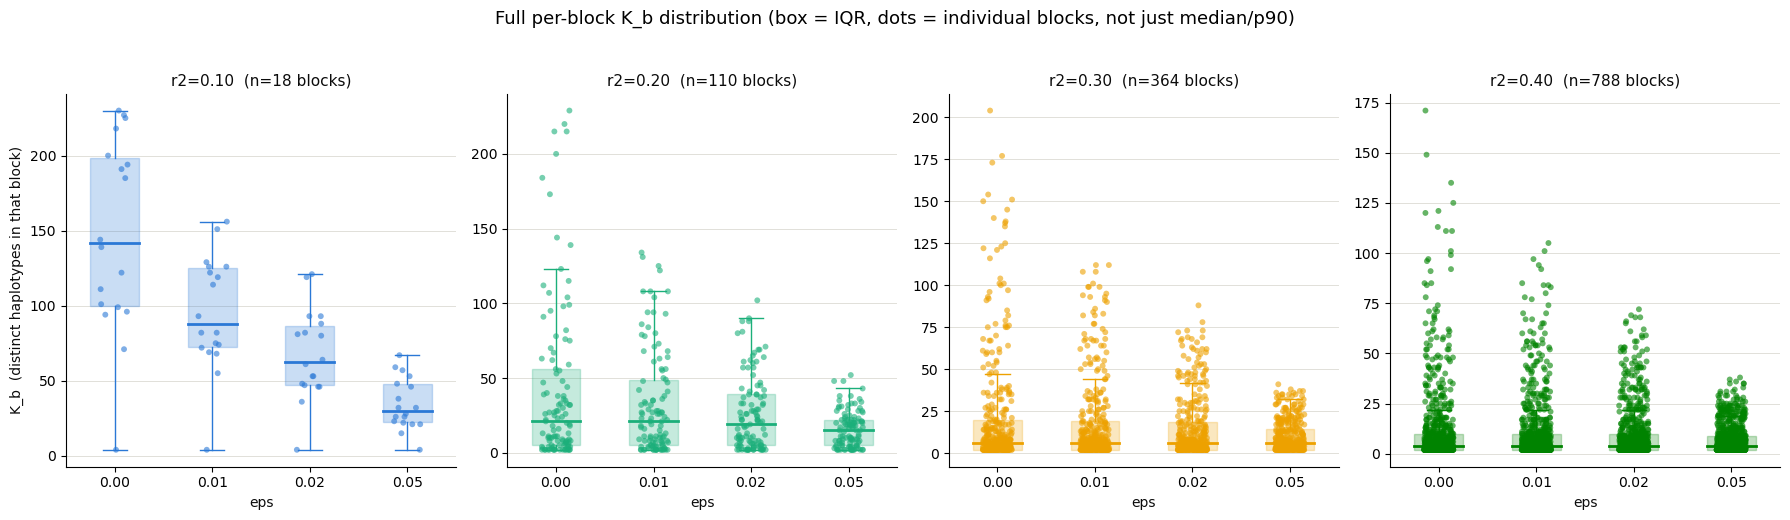

In [2]:

# Full K_b DISTRIBUTION per (r2, eps) -- not just median/p90. Boxplot (IQR/whiskers)
# + jittered individual blocks on top, since some r2 have very few blocks (r2=0.10
# has only 18) where percentile summaries hide the actual per-block spread.
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
for ax, r2 in zip(axes, R2S):
    positions = np.arange(len(EPS))
    data = [RAW[(r2, eps)] for eps in EPS]
    bp = ax.boxplot(data, positions=positions, widths=0.5, showfliers=False,
                     patch_artist=True)
    for patch in bp["boxes"]:
        patch.set(facecolor=COLORS[r2], alpha=0.25, edgecolor=COLORS[r2])
    for med in bp["medians"]:
        med.set(color=COLORS[r2], lw=2)
    for whisk in bp["whiskers"] + bp["caps"]:
        whisk.set(color=COLORS[r2])
    for pos, d in zip(positions, data):
        jitter = rng.uniform(-0.15, 0.15, size=len(d))
        ax.scatter(pos + jitter, d, color=COLORS[r2], s=18, alpha=0.6,
                   edgecolor="none", zorder=3)
    ax.set_xticks(positions); ax.set_xticklabels([f"{e:.2f}" for e in EPS])
    ax.set_xlabel("eps", color=INK)
    ax.set_title(f"r2={r2}  (n={len(data[0])} blocks)", color=INK, fontsize=11)
    ax.grid(True, axis="y", color=GRID, lw=0.7); ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("K_b  (distinct haplotypes in that block)", color=INK)
fig.suptitle("Full per-block K_b distribution (box = IQR, dots = individual blocks, "
             "not just median/p90)", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


### Raw per-block look at r2=0.10, eps=0 (exact identity)

Only 18 blocks at this r2 -- small enough to list every one directly, rather than trust a median.

In [3]:

# r2=0.10 has only 18 blocks on Chr1 -- small enough to show every single one.
# This is the direct look behind the "median K_b=142" number: is it because most
# blocks sit around 142, or is it an average hiding some blocks near 231
# (fully resolved) and others much lower (heavy founder redundancy)?
starts = [b[0] for b in BLOCKINFO["0.10"]]
ends   = [b[1] for b in BLOCKINFO["0.10"]]
nkmers = [b[2] for b in BLOCKINFO["0.10"]]
kb0    = RAW[("0.10", 0.00)]
tbl = pd.DataFrame({"block_start": starts, "block_end": ends,
                     "n_kmers": nkmers, "K_b_exact_identity": kb0,
                     "pct_of_231": (kb0 / F * 100).round(1)}).sort_values("K_b_exact_identity")
tbl


,block_start,block_end,n_kmers,K_b_exact_identity,pct_of_231
17,30418098,30427671,49,4,1.7
10,21357548,22175520,3046,71,30.7
15,26439666,26836014,3098,94,40.7
5,11441491,12268256,3581,96,41.6
6,12268257,14273735,3276,99,42.9
13,25253421,25741226,3462,101,43.7
3,7158367,7729656,4506,111,48.1
14,25741227,26439665,4505,122,52.8
2,6637397,7158366,4168,139,60.2
11,22175521,23489155,5203,144,62.3


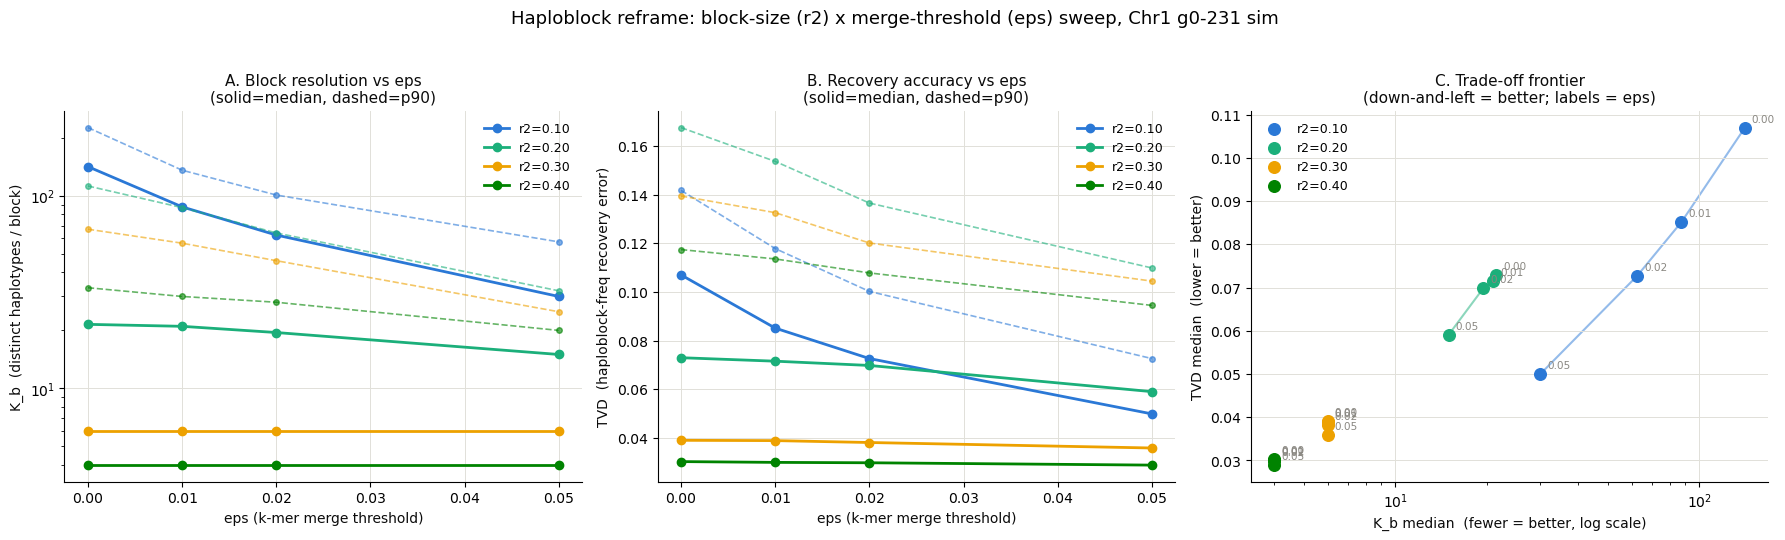

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

# Panel A: Kb vs eps (log y) -- solid = median, dashed = p90
ax = axes[0]
for r2 in R2S:
    d = df[df.r2 == r2].sort_values("eps")
    ax.plot(d.eps, d.Kb_med, "-o", color=COLORS[r2], label=f"r2={r2}", lw=2, ms=6)
    ax.plot(d.eps, d.Kb_p90, "--o", color=COLORS[r2], lw=1.2, ms=4, alpha=0.6)
ax.set_yscale("log")
ax.set_xlabel("eps (k-mer merge threshold)", color=INK)
ax.set_ylabel("K_b  (distinct haplotypes / block)", color=INK)
ax.set_title("A. Block resolution vs eps\n(solid=median, dashed=p90)", color=INK, fontsize=11)
ax.grid(True, color=GRID, lw=0.7); ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=9)

# Panel B: TVD vs eps -- solid = median, dashed = p90
ax = axes[1]
for r2 in R2S:
    d = df[df.r2 == r2].sort_values("eps")
    ax.plot(d.eps, d.TVD_med, "-o", color=COLORS[r2], label=f"r2={r2}", lw=2, ms=6)
    ax.plot(d.eps, d.TVD_p90, "--o", color=COLORS[r2], lw=1.2, ms=4, alpha=0.6)
ax.set_xlabel("eps (k-mer merge threshold)", color=INK)
ax.set_ylabel("TVD  (haploblock-freq recovery error)", color=INK)
ax.set_title("B. Recovery accuracy vs eps\n(solid=median, dashed=p90)", color=INK, fontsize=11)
ax.grid(True, color=GRID, lw=0.7); ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=9)

# Panel C: trade-off scatter, Kb_med (x, log) vs TVD_med (y), points labeled by eps
ax = axes[2]
for r2 in R2S:
    d = df[df.r2 == r2].sort_values("eps")
    ax.plot(d.Kb_med, d.TVD_med, "-", color=COLORS[r2], lw=1.5, alpha=0.5, zorder=1)
    ax.scatter(d.Kb_med, d.TVD_med, color=COLORS[r2], s=70, label=f"r2={r2}", zorder=2)
    for _, row in d.iterrows():
        ax.annotate(f"{row.eps:.2f}", (row.Kb_med, row.TVD_med), fontsize=7.5,
                    color=MUTED, xytext=(5, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("K_b median  (fewer = better, log scale)", color=INK)
ax.set_ylabel("TVD median  (lower = better)", color=INK)
ax.set_title("C. Trade-off frontier\n(down-and-left = better; labels = eps)", color=INK, fontsize=11)
ax.grid(True, color=GRID, lw=0.7); ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=9)

fig.suptitle("Haploblock reframe: block-size (r2) x merge-threshold (eps) sweep, Chr1 g0-231 sim",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


## K-mer coverage per block, by r2

A block can only resolve founders it has enough k-mers to *distinguish* --
a **k-mer-starved block** (very few k-mers spanning it) will show artificially
low K_b / noisy TVD not because founders are actually redundant there, but
because there isn't enough signal to tell them apart. Before picking an r2 we
need to see how many k-mer-starved blocks each r2 choice would create -- a
smaller r2 (bigger blocks) is safer on this axis (fewer, richer blocks) but
worse for collapsing 231 down to few haplotypes; a bigger r2 (tiny blocks) risks
manufacturing K_b collapse that's actually just starvation, not real identifiability.


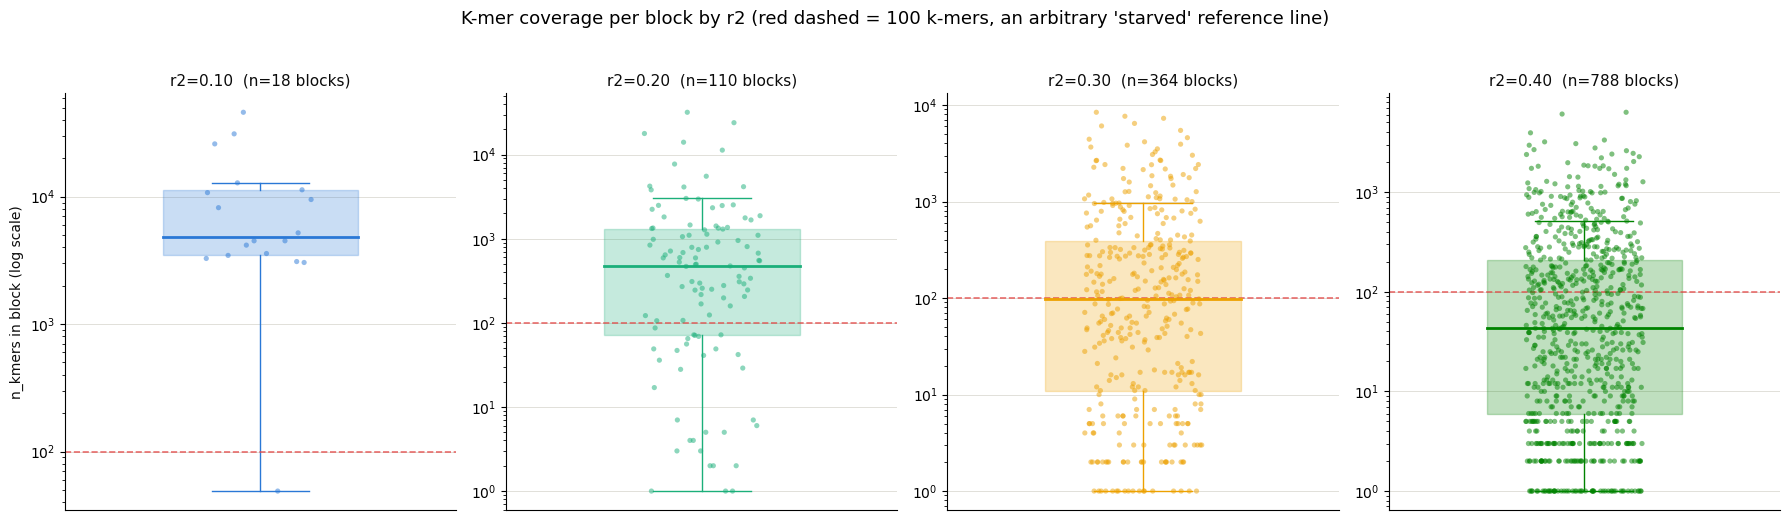

In [5]:

# n_kmers per block distribution, one panel per r2 (log y -- huge dynamic range).
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
for ax, r2 in zip(axes, R2S):
    d = NKMERS[r2]
    ax.boxplot([d], positions=[0], widths=0.5, showfliers=False, patch_artist=True,
               boxprops=dict(facecolor=COLORS[r2], alpha=0.25, edgecolor=COLORS[r2]),
               medianprops=dict(color=COLORS[r2], lw=2),
               whiskerprops=dict(color=COLORS[r2]), capprops=dict(color=COLORS[r2]))
    jitter = rng.uniform(-0.15, 0.15, size=len(d))
    ax.scatter(jitter, d, color=COLORS[r2], s=14, alpha=0.5, edgecolor="none", zorder=3)
    ax.set_yscale("log")
    ax.set_xticks([]); ax.set_title(f"r2={r2}  (n={len(d)} blocks)", color=INK, fontsize=11)
    ax.axhline(100, color="#e34948", lw=1.2, ls="--", alpha=0.8)
    ax.grid(True, axis="y", color=GRID, lw=0.7); ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("n_kmers in block (log scale)", color=INK)
fig.suptitle("K-mer coverage per block by r2 (red dashed = 100 k-mers, an arbitrary "
             "'starved' reference line)", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


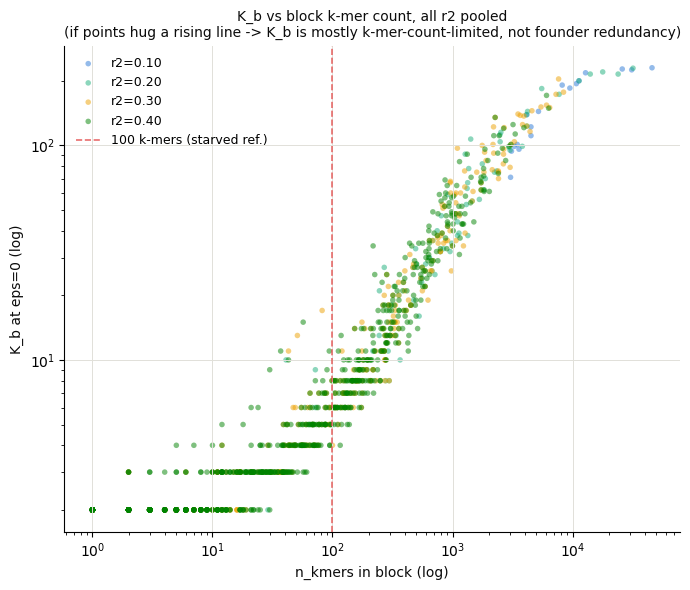

In [6]:

# The actual relationship: does K_b just track n_kmers (starvation), or is there
# real founder collapse happening independent of k-mer count? eps=0 (exact
# identity) shown -- the most conservative / highest-resolution case.
fig, ax = plt.subplots(figsize=(7, 6))
for r2 in R2S:
    ax.scatter(NKMERS[r2], RAW[(r2, 0.00)], color=COLORS[r2], s=16, alpha=0.5,
               label=f"r2={r2}", edgecolor="none")
ax.set_xscale("log"); ax.set_yscale("log")
ax.axvline(100, color="#e34948", lw=1.2, ls="--", alpha=0.8, label="100 k-mers (starved ref.)")
ax.set_xlabel("n_kmers in block (log)", color=INK)
ax.set_ylabel("K_b at eps=0 (log)", color=INK)
ax.set_title("K_b vs block k-mer count, all r2 pooled\n"
             "(if points hug a rising line -> K_b is mostly k-mer-count-limited, "
             "not founder redundancy)", color=INK, fontsize=10)
ax.grid(True, color=GRID, lw=0.7); ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


In [7]:

# Practical decision table: for each r2, what fraction of blocks fall below
# plausible "starved" k-mer floors? This is the number that should gate an r2
# choice -- a low-K_b median is meaningless if it's driven by starved blocks.
floors = [50, 100, 250, 500, 1000]
frows = []
for r2 in R2S:
    d = NKMERS[r2]
    row = {"r2": r2, "n_blocks": len(d), "median_n_kmers": int(np.median(d))}
    for f in floors:
        row[f"pct_below_{f}"] = round(100 * (d < f).mean(), 1)
    frows.append(row)
floor_df = pd.DataFrame(frows)
floor_df


,r2,n_blocks,median_n_kmers,pct_below_50,pct_below_100,pct_below_250,pct_below_500,pct_below_1000
0,0.10,18,4854,5.6,5.6,5.6,5.6,5.6
1,0.20,110,472,21.8,28.2,38.2,52.7,69.1
2,0.30,364,97,40.7,50.5,64.3,77.7,86.3
3,0.40,788,43,51.6,62.1,77.5,86.8,94.0


## K-mer-floor-restricted re-analysis

The raw sweep (panels A/B/C above) mixes well-powered and k-mer-starved blocks
together, and the coverage panels just showed that's a real confound: at
r2=0.30 the *median* block has only 97 k-mers, at r2=0.40 only 43 -- both
already under a plausible "starved" line, so their attractively-low K_b_med
may be starvation, not real haplotype collapse. Here the same K_b/TVD scoring
is **recomputed restricted to blocks with n_kmers >= floor**, at floor = 0
(original, no filter -- sanity check it reproduces the table above), 500, and
1000, so the collinearity-collapse claim can be checked on well-powered blocks
only.


In [8]:

FLOORS = [0, 500, 1000]
frows2 = []
for floor in FLOORS:
    for r2 in R2S:
        mask = NKMERS[r2] >= floor
        n_kept = int(mask.sum())
        for eps in EPS:
            kb = RAW[(r2, eps)][mask]
            tvd = RAW_TVD[(r2, eps)][mask]
            frows2.append(dict(floor=floor, r2=r2, eps=eps,
                                n_blocks_kept=n_kept,
                                pct_kept=round(100 * n_kept / len(mask), 1),
                                Kb_med=np.median(kb) if n_kept else np.nan,
                                TVD_med=np.median(tvd) if n_kept else np.nan))
floor_df = pd.DataFrame(frows2)
floor_df


,floor,r2,eps,n_blocks_kept,pct_kept,Kb_med,TVD_med
0,0,0.10,0.00,18,100.0,141.5,0.106988
1,0,0.10,0.01,18,100.0,87.5,0.085155
2,0,0.10,0.02,18,100.0,62.5,0.072664
3,0,0.10,0.05,18,100.0,30.0,0.049942
4,0,0.20,0.00,110,100.0,21.5,0.073007
5,0,0.20,0.01,110,100.0,21.0,0.071579
6,0,0.20,0.02,110,100.0,19.5,0.069825
7,0,0.20,0.05,110,100.0,15.0,0.059080
8,0,0.30,0.00,364,100.0,6.0,0.039097
9,0,0.30,0.01,364,100.0,6.0,0.038971


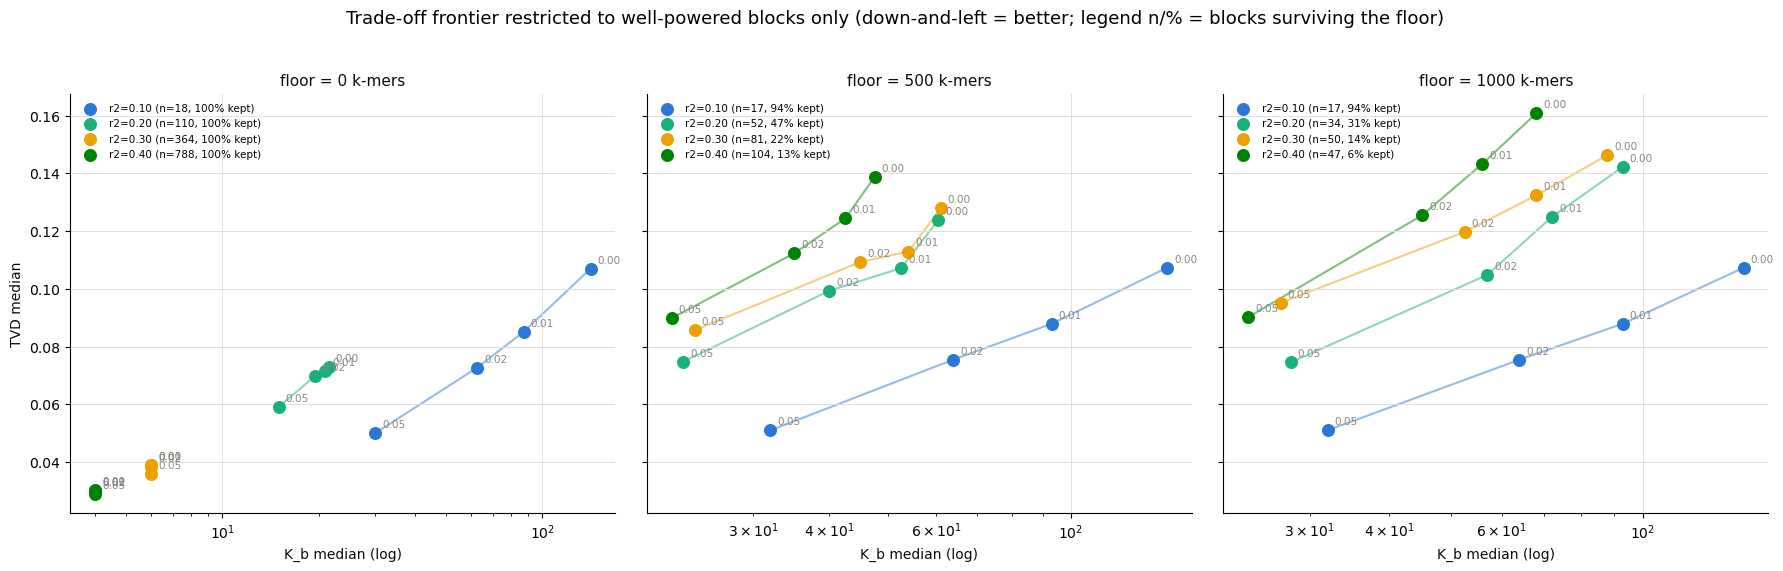

In [9]:

# Trade-off frontier (Panel C style), one subplot per k-mer floor. If the
# frontier barely moves from floor=0 -> floor=1000, the original collapse was
# real; if r2=0.30/0.40 swing sharply toward higher K_b once starved blocks are
# dropped, the earlier "sweet spot" reading was mostly a starvation artifact.
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
for ax, floor in zip(axes, FLOORS):
    sub = floor_df[floor_df.floor == floor]
    for r2 in R2S:
        d = sub[sub.r2 == r2].sort_values("eps")
        if d.n_blocks_kept.iloc[0] == 0:
            continue
        ax.plot(d.Kb_med, d.TVD_med, "-", color=COLORS[r2], lw=1.5, alpha=0.5, zorder=1)
        ax.scatter(d.Kb_med, d.TVD_med, color=COLORS[r2], s=70,
                   label=f"r2={r2} (n={d.n_blocks_kept.iloc[0]}, {d.pct_kept.iloc[0]:.0f}% kept)",
                   zorder=2)
        for _, row in d.iterrows():
            ax.annotate(f"{row.eps:.2f}", (row.Kb_med, row.TVD_med), fontsize=7.5,
                        color=MUTED, xytext=(5, 4), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("K_b median (log)", color=INK)
    ax.set_title(f"floor = {floor} k-mers", color=INK, fontsize=11)
    ax.grid(True, color=GRID, lw=0.7); ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=7.5, loc="upper left")
axes[0].set_ylabel("TVD median", color=INK)
fig.suptitle("Trade-off frontier restricted to well-powered blocks only "
             "(down-and-left = better; legend n/% = blocks surviving the floor)",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


## Scope caveat

This sweep uses **Chr1 only** -- the filt2inv k-mer panel hasn't been built for
the other chromosomes yet, so `n_blocks` and the K_b/TVD distributions above
are a single-chromosome estimate, not genome-wide. Extend to Chr2-5 before
finalizing an r2/eps choice for production.
